In [7]:
import torch

# Torch (and PyTorch) PyTorch is one of the most popular frameworks for
#  developing and training machine learning and deep learning models.

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# CUDA (Compute Unified Device Architecture) is a parallel computing platform
# and programming model developed by NVIDIA for their GPUs. CUDA harness the
# highly parallel processing power of GPUs to perform general-purpose computing
# tasks (i.e., tasks beyond traditional graphics rendering).


Using device: cuda


Using device: cuda


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/20 [00:00<?, ?it/s]

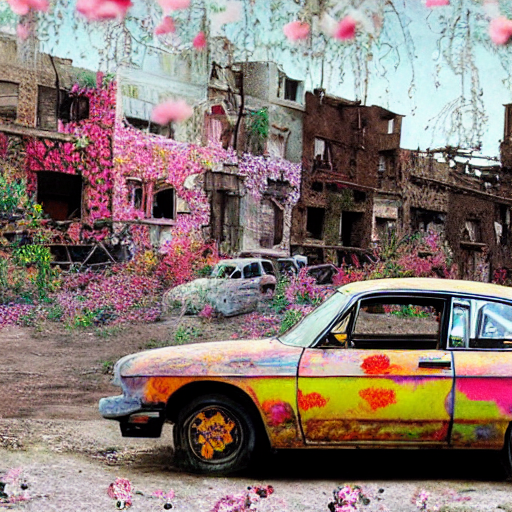

In [28]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


prompt = (
    "drawing of an abandoned car with flowers around it, rusty car, birds, spring, abandonned building, "
    "vivid colors, detailed, art station, highly detailed, smooth, sharp focus, illustration, global illumination, "
    "cut-out paper textures, newspaper elements, text, "
)

negative_prompt = (
    "lowres, watermark, text "
    "oversaturated, "
) # This is what the model steers away from.

model_id = "runwayml/stable-diffusion-v1-5" # Reverting to a smaller model as requested
pipe = StableDiffusionPipeline.from_pretrained(model_id, safety_checker=None)
pipe = pipe.to(device)

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    generator=torch.Generator(device).manual_seed(110419), # change the seed!
    num_inference_steps=20, guidance_scale=7.0
).images[0]

image

In [7]:
image.save("prompt_image3.png")